# 04 — Análisis exploratorio: evolución temporal, geográfica y por fabricante

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

A diferencia de los cuadernos anteriores, este trabaja sobre los **agregados de
población** calculados en el servidor de la EEA, no sobre la muestra del 10 %.
Las cifras se refieren por tanto a los 10.782.314 vehículos de 2024 y a los
40,9 millones del periodo 2021-2024.

Objetivo: caracterizar la trayectoria del mercado bajo el Reglamento (UE)
2019/631, situar a los Estados miembros y a los fabricantes frente al objetivo
de flota, y resolver la falta de normalización del campo de marca. Cierra el
apartado 4.3 de la memoria.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
AGREGADOS = RAIZ / "datos" / "agregados"


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


MILES = FuncFormatter(lambda v, _: es(v))

# El campo de combustible cambia de mayúsculas entre años (DIESEL en 2021,
# diesel desde 2022). Sin normalizar, la serie se parte en categorías duplicadas.
tendencia = pd.read_csv(AGREGADOS / "tendencia_anio_combustible.csv")
tendencia["Combustible"] = tendencia["Combustible"].str.lower().str.strip()
tendencia = tendencia.dropna(subset=["CO2_medio_wltp"])

CERO    = ["electric", "hydrogen"]
ENCHUFE = ["petrol/electric", "diesel/electric"]
tendencia["regimen"] = np.where(tendencia["Combustible"].isin(CERO), "Cero emisiones",
                        np.where(tendencia["Combustible"].isin(ENCHUFE), "Híbrido enchufable",
                                 "Combustión"))

ORDEN_REG = ["Cero emisiones", "Híbrido enchufable", "Combustión"]
COLOR_REG = [estilo.PALETA[5], estilo.PALETA[2], estilo.PALETA[0]]
# El objetivo de 95 g/km del Reglamento está expresado en NEDC y estos datos son
# WLTP. La referencia comparable es el objetivo WLTP vigente desde 2025: 93,6 g/km,
# un 15 % por debajo de la referencia de flota de 2021 (unos 110 g/km WLTP).
OBJETIVO = 93.6
ETIQUETA_OBJ = "objetivo 2025: 93,6 g/km"

print("Años:", sorted(tendencia["Anio"].unique()))
print("Combustibles:", sorted(tendencia["Combustible"].unique()))

Años: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Combustibles: ['diesel', 'diesel/electric', 'e85', 'electric', 'hydrogen', 'lpg', 'ng', 'ng-biomethane', 'petrol', 'petrol/electric', 'unknown']


## 1. Trayectoria de la flota europea, 2021-2024

La media que fija el reglamento es la del conjunto de la flota, ponderada por
unidades matriculadas. Se reconstruye a partir de las medias por combustible y
sus volúmenes.

In [2]:
flota = tendencia.groupby("Anio").apply(lambda d: pd.Series({
    "vehiculos":      d.Vehiculos.sum(),
    "co2_flota":      (d.CO2_medio_wltp * d.Vehiculos).sum() / d.Vehiculos.sum(),
    "masa_media":     (d.Masa_media_kg  * d.Vehiculos).sum() / d.Vehiculos.sum(),
    "pct_cero":       100 * d.loc[d.regimen == "Cero emisiones", "Vehiculos"].sum() / d.Vehiculos.sum(),
    "pct_enchufable": 100 * d.loc[d.regimen == "Híbrido enchufable", "Vehiculos"].sum() / d.Vehiculos.sum(),
    "pct_combustion": 100 * d.loc[d.regimen == "Combustión", "Vehiculos"].sum() / d.Vehiculos.sum(),
}), include_groups=False)

print(flota.round(2).to_string())

       vehiculos  co2_flota  masa_media  pct_cero  pct_enchufable  pct_combustion
Anio                                                                             
2021   9920521.0     114.24     1485.75     10.09            9.14           80.78
2022   9479544.0     108.27     1526.65     13.48            9.49           77.03
2023  10734898.0     106.53     1544.59     15.56            7.82           76.62
2024  10782314.0     106.78     1558.77     14.55            7.18           78.26


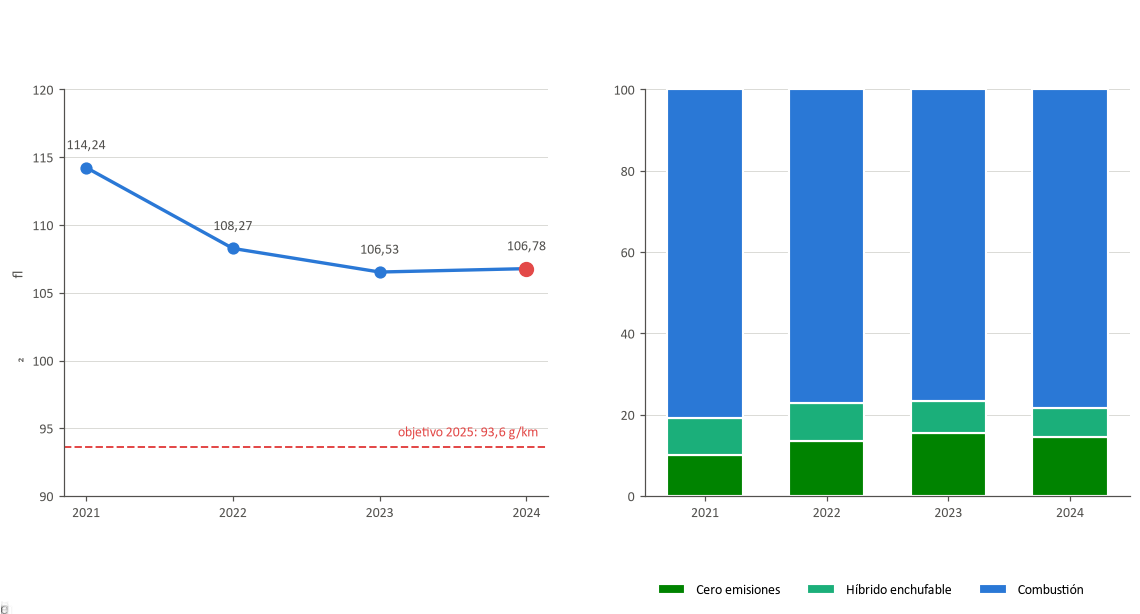

In [3]:
cuota = (tendencia.pivot_table(index="Anio", columns="regimen",
                               values="Vehiculos", aggfunc="sum")
         .fillna(0).pipe(lambda d: 100 * d.div(d.sum(axis=1), axis=0)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax1.plot(flota.index, flota["co2_flota"], marker="o", ms=7, lw=2.2,
         color=estilo.PALETA[0], zorder=3)
# El último año se marca en rojo por ser el primer repunte de la serie
ax1.plot(flota.index[-1], flota["co2_flota"].iloc[-1], marker="o", ms=9,
         color=estilo.PALETA[7], zorder=4)
for a, v in flota["co2_flota"].items():
    ax1.annotate(es(v, 2), (a, v), textcoords="offset points", xytext=(0, 12),
                 ha="center", fontsize=9, color=estilo.GRIS_EJES)
ax1.axhline(OBJETIVO, color=estilo.PALETA[7], ls="--", lw=1.3)
ax1.text(flota.index[-1] + 0.08, OBJETIVO + 0.8, ETIQUETA_OBJ,
         ha="right", fontsize=9, color=estilo.PALETA[7])
ax1.set_xticks(flota.index)
ax1.set_ylim(90, 120)
ax1.set_ylabel("CO₂ medio de la flota (g/km)")
ax1.set_title("Emisiones medias del parque matriculado", fontsize=11, pad=10, loc="left")
ax1.grid(axis="x", visible=False)

abajo = np.zeros(len(cuota))
for r, c in zip(ORDEN_REG, COLOR_REG):
    ax2.bar(cuota.index, cuota[r], bottom=abajo, color=c, label=r, width=0.62,
            edgecolor="white", linewidth=1.4)
    for x, (b, v) in enumerate(zip(abajo, cuota[r])):
        if v > 4:
            ax2.text(cuota.index[x], b + v / 2, f"{es(v, 1)} %", ha="center",
                     va="center", fontsize=8.5, color="white")
    abajo = abajo + cuota[r].values
ax2.set_xticks(cuota.index)
ax2.set_ylim(0, 100)
ax2.set_ylabel("Cuota de matriculaciones (%)")
ax2.set_title("Composición del mercado por régimen tecnológico", fontsize=11,
              pad=10, loc="left")
ax2.legend(frameon=False, fontsize=9, loc="lower left",
           bbox_to_anchor=(0, -0.28), ncol=3)
ax2.grid(axis="x", visible=False)

fig.suptitle("Evolución de las emisiones y de la composición del mercado, 2021-2024",
             fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_04_evolucion.png")
plt.show()

## 2. Distribución geográfica

La comparación entre países pone a prueba la intuición de que las flotas menos
contaminantes son las de vehículos más pequeños.

In [4]:
pais = pd.read_csv(AGREGADOS / "resumen_por_pais.csv")
r = pais[["Masa_media_kg", "CO2_medio_wltp"]].corr().iloc[0, 1]

orden = pais.sort_values("CO2_medio_wltp")
print("--- cinco menores emisiones ---")
print(orden.head(5).round(1).to_string(index=False))
print("\n--- cinco mayores emisiones ---")
print(orden.tail(5).round(1).to_string(index=False))
print(f"\nCorrelación masa-emisiones entre países: r = {r:.3f}")

--- cinco menores emisiones ---
Pais  Vehiculos  CO2_medio_wltp  Masa_media_kg  Potencia_media_kw
  NO     128602            11.8         2036.3              230.1
  DK     171622            60.3         1779.4              160.2
  SE     267628            62.0         1866.0              175.7
  FI      71813            64.8         1743.2              131.0
  NL     377395            65.3         1638.6              132.6

--- cinco mayores emisiones ---
Pais  Vehiculos  CO2_medio_wltp  Masa_media_kg  Potencia_media_kw
  BG      42011           130.7         1555.6              120.0
  EE      25396           131.8         1642.2              124.8
  CZ     227734           132.3         1545.1              115.2
  PL     539863           133.2         1562.8              115.1
  SK      91593           135.3         1540.0              111.2

Correlación masa-emisiones entre países: r = -0.686


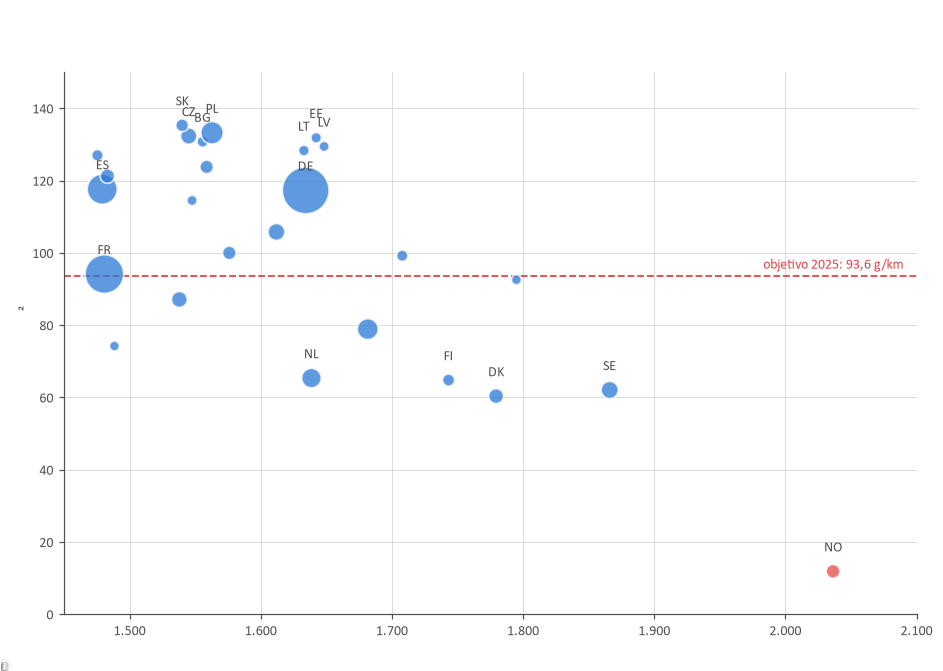

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.4))

tam = 40 + 900 * pais.Vehiculos / pais.Vehiculos.max()
color = [estilo.PALETA[7] if c == "NO" else estilo.PALETA[0] for c in pais.Pais]
ax.scatter(pais.Masa_media_kg, pais.CO2_medio_wltp, s=tam, c=color, alpha=0.75,
           edgecolor="white", linewidth=1.2, zorder=3)

# Se rotulan los mercados de mayor volumen y los casos extremos
DESTACADOS = {"NO", "SK", "PL", "DE", "ES", "IT", "FR", "DK", "SE", "NL"}
for _, f in pais.iterrows():
    if f.Pais in DESTACADOS or f.CO2_medio_wltp > 128 or f.CO2_medio_wltp < 70:
        ax.annotate(f.Pais, (f.Masa_media_kg, f.CO2_medio_wltp),
                    textcoords="offset points", xytext=(0, 13), ha="center",
                    fontsize=9, color=estilo.GRIS_EJES, zorder=4)

ax.axhline(OBJETIVO, color=estilo.PALETA[7], ls="--", lw=1.2, zorder=1)
ax.text(2090, OBJETIVO + 2, ETIQUETA_OBJ, ha="right",
        fontsize=9, color=estilo.PALETA[7])
ax.set_xlabel("Masa media del vehículo matriculado (kg)")
ax.set_ylabel("Emisiones medias de CO₂ WLTP (g/km)")
ax.set_xlim(1450, 2100)
ax.set_ylim(0, 150)
ax.xaxis.set_major_formatter(MILES)
ax.set_title("Emisiones y masa media por país de matriculación\n"
             f"Los 29 Estados del conjunto, 2024. Correlación r = {es(r, 2)}",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_05_paises.png")
plt.show()

## 3. Normalización del campo de marca

El campo llega sin normalizar desde origen. El criterio adoptado corta la
denominación por la barra, que separa al fabricante del carrocero en las
conversiones, y asigna después la marca canónica por prefijo. Lo que no encaja
en ninguna conserva su primera palabra.

In [6]:
CANONICAS = ["MERCEDES", "VOLKSWAGEN", "ALFA ROMEO", "LAND ROVER", "GREAT WALL",
             "MITSUBISHI", "SSANGYONG", "ASTON MARTIN", "ROLLS ROYCE", "MG",
             "CITROEN", "FORD", "OPEL", "TOYOTA", "SKODA", "RENAULT", "BMW",
             "PEUGEOT", "DACIA", "AUDI", "HYUNDAI", "KIA", "VOLVO", "TESLA",
             "FIAT", "SEAT", "NISSAN", "CUPRA", "SUZUKI", "MAZDA", "JEEP",
             "MINI", "PORSCHE", "LEXUS", "HONDA", "LANCIA", "SMART", "POLESTAR",
             "SUBARU", "JAGUAR", "BYD"]
CANONICAS = sorted(CANONICAS, key=len, reverse=True)   # el prefijo más largo gana
EXCEPCIONES = {"CITROEN DS": "DS"}                     # marca propia del grupo


def normaliza_marca(marca):
    s = str(marca).strip().upper()
    s = s.split("/")[0].strip()          # descarta el carrocero de las conversiones
    s = " ".join(s.split())              # colapsa espacios repetidos
    if s in EXCEPCIONES:
        return EXCEPCIONES[s]
    for c in CANONICAS:
        if s.startswith(c):
            return c
    return s.split(" ")[0]


marca = pd.read_csv(AGREGADOS / "resumen_por_marca.csv")
marca = marca[marca["Marca"].notna()]
marca["marca_norm"] = marca["Marca"].map(normaliza_marca)
marca["co2_x_v"] = marca.CO2_medio_wltp * marca.Vehiculos

fabricantes = marca.groupby("marca_norm").agg(vehiculos=("Vehiculos", "sum"),
                                              co2_x_v=("co2_x_v", "sum"))
fabricantes["co2"] = fabricantes.co2_x_v / fabricantes.vehiculos
fabricantes = fabricantes.sort_values("vehiculos", ascending=False)

print(f"Denominaciones en origen: {len(marca)}")
print(f"Marcas tras normalizar:   {len(fabricantes)}")
print("\nEfecto sobre Volkswagen, que llegaba repartido en varias grafías:")
print(marca.loc[marca.marca_norm == "VOLKSWAGEN", ["Marca", "Vehiculos"]]
      .sort_values("Vehiculos", ascending=False).to_string(index=False))
print("\n--- doce primeras marcas tras normalizar ---")
print(fabricantes.head(12)[["vehiculos", "co2"]].round(1).to_string())

Denominaciones en origen: 450
Marcas tras normalizar:   279

Efecto sobre Volkswagen, que llegaba repartido en varias grafías:
                Marca  Vehiculos
        VOLKSWAGEN VW     612768
           VOLKSWAGEN     535573
       VOLKSWAGEN  VW       8198
       VOLKSWAGEN. VW       3399
     VOLKSWAGEN/V-VAN         30
     VOLKSWAGEN/KNAUS         27
    VOLKSWAGEN/CARPOL         21
     VOLKSWAGEN/ZIMNY          6
 VOLKSWAGEN AMZ KUTNO          4
  VOLKSWAGEN/MOBILCAR          2
     VOLKSWAGEN/HOBBY          2
     VOLKSWAGEN/ERIBA          2
VOLKSWAGEN MOTORSPORT          1
   VOLKSWAGEN BENNETT          1
    VOLKSWAGEN/FURGOK          1
       VOLKSWAGEN/MRC          1
       VOLKSWAGEN-USA          1

--- doce primeras marcas tras normalizar ---
            vehiculos    co2
marca_norm                  
VOLKSWAGEN    1160037  117.8
TOYOTA         818735  106.3
SKODA          666353  115.9
RENAULT        657949  104.7
BMW            623816  101.1
PEUGEOT        586893  105.2
M

## 4. Fabricantes frente al objetivo de flota

El objetivo de 95 g/km se aplica por agrupación de fabricantes y no por marca
comercial, de modo que la comparación es indicativa y no determina el
cumplimiento formal de ninguna de ellas.

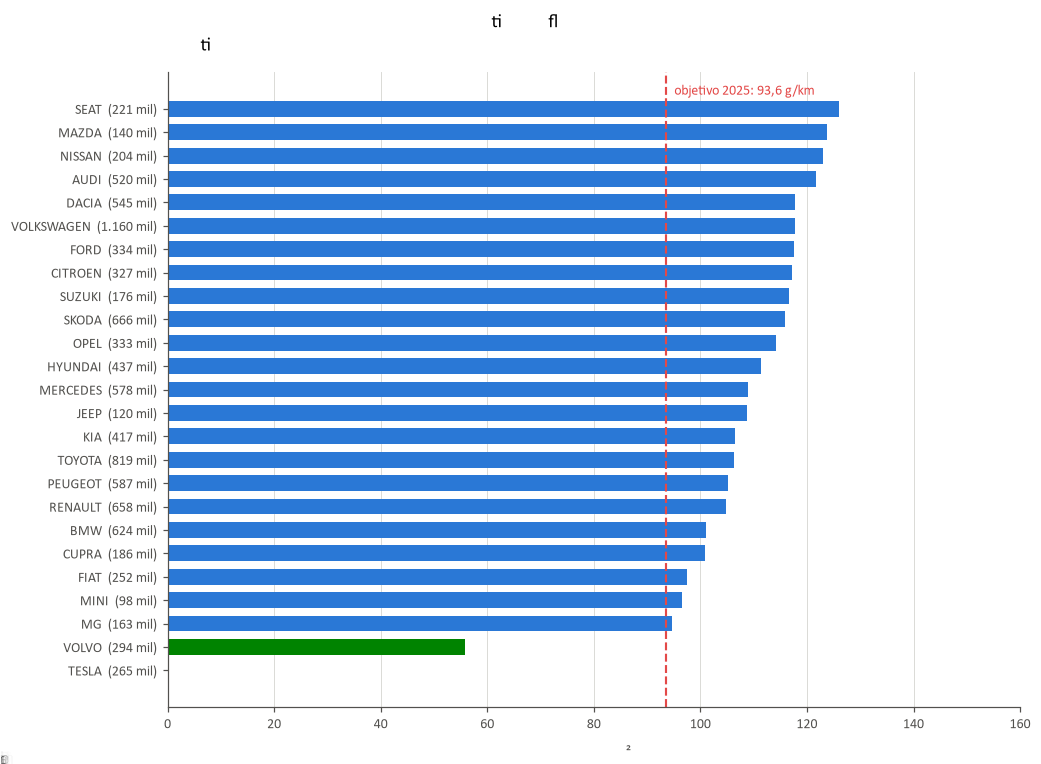

De las 25 marcas de mayor volumen, 2 se sitúan en el objetivo o por debajo.


In [7]:
top = fabricantes.head(25).sort_values("co2")

fig, ax = plt.subplots(figsize=(10, 7.5))
color = [estilo.PALETA[5] if v <= OBJETIVO else estilo.PALETA[0] for v in top.co2]
ax.barh(range(len(top)), top.co2, color=color, height=0.68)

for i, v in enumerate(top.co2):
    ax.text(v + 2, i, es(v, 1), va="center", fontsize=8.5, color=estilo.GRIS_EJES)
# Marca visible para las de cero emisiones, cuya barra tendría longitud nula
for i, v in enumerate(top.co2):
    if v == 0:
        ax.plot(0, i, marker="|", ms=14, color=estilo.PALETA[5])

ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{n}  ({es(top.vehiculos[n] / 1000)} mil)" for n in top.index],
                   fontsize=9)
ax.axvline(OBJETIVO, color=estilo.PALETA[7], ls="--", lw=1.4)
ax.text(OBJETIVO + 1.5, len(top) - 0.4, ETIQUETA_OBJ, fontsize=9,
        color=estilo.PALETA[7])
ax.set_xlabel("Emisiones medias de CO₂ WLTP (g/km)")
ax.set_xlim(0, 160)
ax.grid(axis="y", visible=False)
ax.set_title("Emisiones medias por marca frente al objetivo de flota\n"
             "Veinticinco marcas de mayor volumen, UE 2024",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_06_marcas.png")
plt.show()

cumplen = (top.co2 <= OBJETIVO).sum()
print(f"De las 25 marcas de mayor volumen, {cumplen} se sitúan en el objetivo o por debajo.")